# Caustics, binary labels, distances, and winding numbers

The first row constructs four registered source-plane products from one lens
realization. It includes point-source magnification, modulo-two caustic parity, distance
to the nearest caustic, and integer winding number.  The winding product needs
consistently oriented *closed* caustic contours. The package orients marching-
squares segments by the positive-$\det A$ side before mapping them through the
lens equation.  Consequently its value is piecewise constant and changes only
across a plotted caustic, while its value modulo two exactly reproduces the
binary map.

The second figure reproduces the Q2237 image-B manuscript anchor/gauge panel
with the same classified probes, ray colors, scale bar, and legend placement.
The full diagnostic maps are optional—the fast light-curve pipeline normally
evaluates only the source-center quantities.


In [1]:
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
stars = mc.PointMassField(
        x_uas=torch.tensor([-0.8, 0.4, 1.1]),
        y_uas=torch.tensor([0.5, -0.7, 0.2]),
        einstein_radius_uas=torch.tensor([0.25, 0.20, 0.18]),
)
lens_region = mc.PlaneRegion((6.0, 6.0))
lens_resolution = 2048 if use_cuda else 768
lens_grid = mc.PlaneGrid((lens_resolution, lens_resolution), (6.0, 6.0))
# This crop is centered on a resolved caustic rather than on an empty part of
# the source plane. PlaneGrid centers use array order (y, x).
source_resolution = 1024 if use_cuda else 256
source_grid = mc.PlaneGrid(
    (source_resolution, source_resolution),
    (0.60, 0.60),
    center_uas=(-0.68, 0.35),
)
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.25, shear=0.10),
    distances=mc.LensingDistances(8.0e24, 1.6e25, 9.0e24),
    stars=stars, source_grid=source_grid, lens_region=lens_region,
    runtime=runtime_config, caustic_grid_shape=lens_grid.shape,
)
simulation = system.realize().simulation  # full diagnostic maps use the resolved tracer
ray_count = 10_000_000 if use_cuda else 262_144


In [3]:
magnification = simulation.magnification_map(
    lens_region,
    source_grid,
    method=mc.production_ipm_config(
        dynamic=False, rays=ray_count,
        cell_chunk_size=524_288 if use_cuda else 65_536,
    ),
)
complete_field = simulation.caustics(lens_grid)
binary_map = complete_field.label_map(source_grid)
distance_map = complete_field.distance_map(source_grid)
winding_map = complete_field.winding_map(source_grid, orientation="positive")

torch.testing.assert_close(
    torch.remainder(winding_map.values, 2).to(binary_map.values.dtype),
    binary_map.values,
    rtol=0,
    atol=0,
)
print("critical/caustic segments:", complete_field.segment_count)
print("winding values:", torch.unique(winding_map.values).tolist())
print("source-center winding number:", int(winding_map.values[source_grid.shape[0] // 2, source_grid.shape[1] // 2].cpu()))


critical/caustic segments: 1724
winding values: [0, 1]
source-center winding number: 0


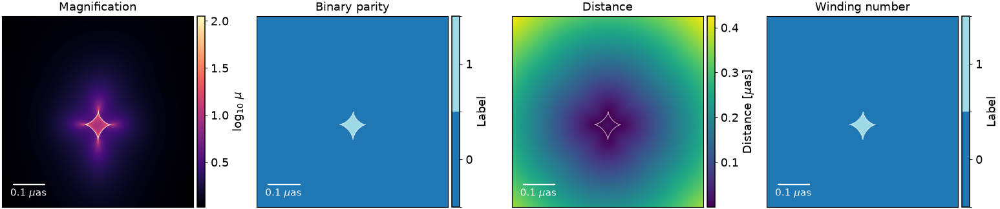

In [4]:
figure, axes = plt.subplots(1, 4, figsize=(15.8, 3.7))
mcp.plot_magnification_map(
    magnification,
    ax=axes[0],
    caustics=complete_field,
    log10=True,
    colorbar=True,
    title=r"Magnification",
    scale_bar_uas=0.1,
    show_axes=False,
)
mcp.plot_label_map(
    binary_map,
    ax=axes[1],
    caustics=complete_field,
    colorbar=True,
    title="Binary parity",
    scale_bar_uas=0.1,
    show_axes=False,
)
mcp.plot_distance_map(
    distance_map,
    ax=axes[2],
    caustics=complete_field,
    colorbar=True,
    scale_bar_uas=0.1,
    show_axes=False,
)
axes[2].set_title("Distance")
mcp.plot_label_map(
    winding_map,
    ax=axes[3],
    caustics=complete_field,
    colorbar=True,
    title="Winding number",
    scale_bar_uas=0.1,
    show_axes=False,
)
figure.tight_layout()


## Production anchor/gauge labeling at full source-map resolution

The next cell reconstructs the optional $1024\times1024$ Q2237 image-B diagnostic maps from the saved same-epoch caustic segments, rather than displaying a pre-rendered image. Production light curves do not materialize these maps. They evaluate only the configurable anchors, gauges, and source center. The full binary and distance fields are useful for validation and visualization.


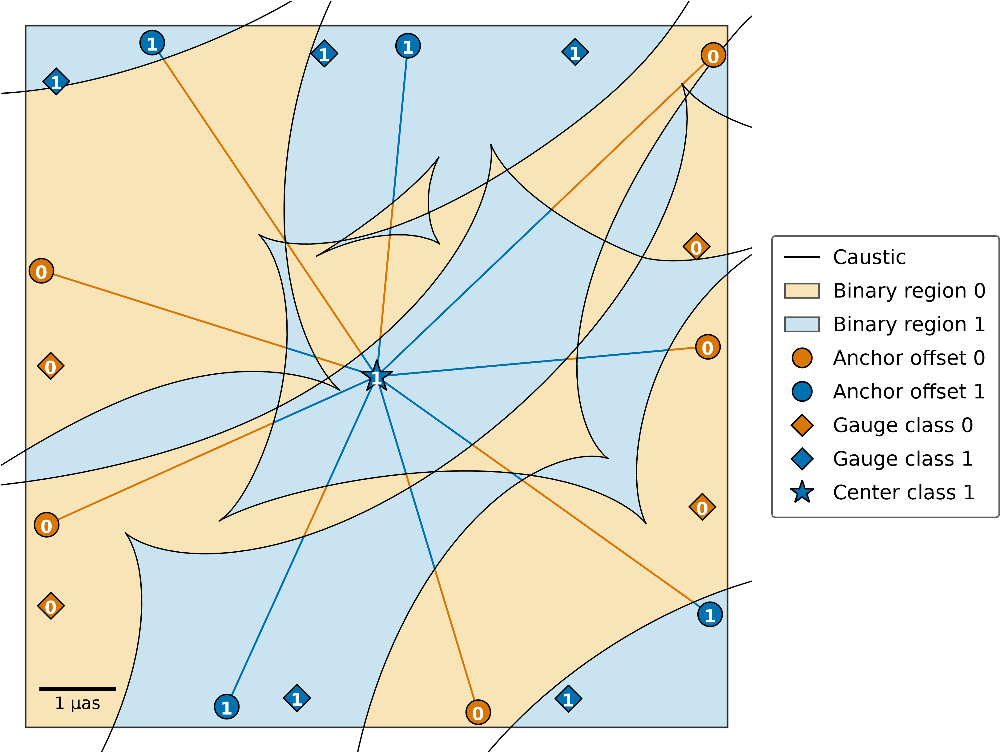

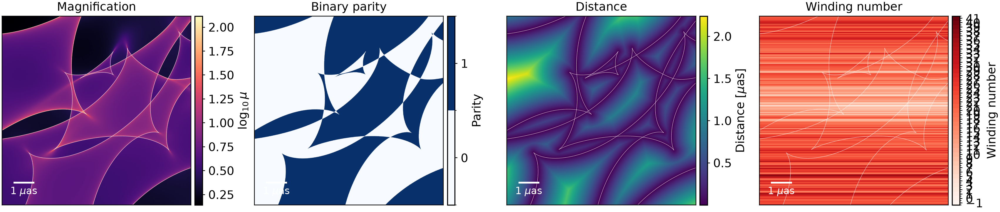

Q2237 diagnostic resolution: torch.Size([1024, 1024])


In [5]:
def locate_workspace_root():
    candidates = (Path(mcp.__file__).resolve().parents[4], Path.cwd(), *Path.cwd().parents)
    return next(
        path for path in candidates
        if (path / "output" / "final_paper_run_production_v4").is_dir()
    )

workspace = locate_workspace_root()
comparison_path = (
    workspace / "output" / "final_paper_run_production_v4" / "quasar"
    / "Q2237+0305_image_B" / "results_paper_benchmark"
    / "paper_method_map_caustic_comparison_data.npz"
)
with np.load(comparison_path, allow_pickle=True) as payload:
    source_extent = np.asarray(payload["source_extent"], dtype=float)
    segments = torch.as_tensor(
        payload["anchor_gauge_caustic_segments"], device=simulation.runtime.device,
        dtype=simulation.runtime.dtype,
    )
    anchors = torch.as_tensor(payload["anchor_gauge_anchor_points"], dtype=torch.float32)
    anchor_classes = torch.as_tensor(payload["anchor_gauge_anchor_labels"], dtype=torch.int8)
    gauges = torch.as_tensor(payload["anchor_gauge_gauge_points"], dtype=torch.float32)
    gauge_classes = torch.as_tensor(payload["anchor_gauge_gauge_labels"], dtype=torch.int8)
    center = torch.as_tensor(payload["anchor_gauge_center_point"], dtype=torch.float32)
    center_class = int(payload["anchor_gauge_center_label"])
    q_magnification = np.asarray(payload["method_0_mag_map"], dtype=np.float32)
    complete_winding_image_segments = np.asarray(payload["reference_segments_img"], dtype=np.float64)
    complete_winding_source_segments = np.asarray(payload["reference_segments_src"], dtype=np.float64)

q_fov = (source_extent[1] - source_extent[0], source_extent[3] - source_extent[2])
q_center = (0.5 * (source_extent[2] + source_extent[3]), 0.5 * (source_extent[0] + source_extent[1]))
q_grid = mc.PlaneGrid((1024, 1024), q_fov, center_uas=q_center)
q_field = mc.CausticField(
    segments,
    segments,
    mc.PlaneGrid((2, 2), q_fov, center_uas=q_center),
)
from microcaustics.caustics import anchor_gauge_label_map
registered_binary = anchor_gauge_label_map(
    q_field,
    q_grid,
    anchors.to(segments.device),
    anchor_classes,
    frame_xor=0,
    config=mc.CausticConfig(point_chunk_size=4096, segment_chunk_size=4096),
)
q_distance = q_field.distance_map(q_grid, point_chunk_size=4096, segment_chunk_size=4096)
# These frozen reference segments come directly from microcaustics marching
# squares and already retain their determinant-side orientation. Keep that
# orientation instead of treating them as unoriented external polylines.
registered_complete_field = mc.CausticField(
    torch.as_tensor(complete_winding_image_segments, device=simulation.runtime.device, dtype=torch.float64),
    torch.as_tensor(complete_winding_source_segments, device=simulation.runtime.device, dtype=torch.float64),
    q_field.lens_grid,
)
winding_values = (
    registered_complete_field.winding_map(q_grid, orientation="positive")
    .values.cpu().numpy()
)
labels = mc.AnchorGaugeLabels(
    raw_center_label=center_class,
    center_label=center_class,
    center_crossing=False,
    center_distance_uas=float(q_field.distance(center.to(segments.device)[None])[0].cpu()),
    center_vote_count=len(anchors),
    center_valid_count=len(anchors),
    gauge_labels=gauge_classes,
    gauge_distances_uas=q_field.distance(gauges.to(segments.device)).cpu(),
    gauge_vote_counts=torch.full((len(gauges),), len(anchors), dtype=torch.int32),
    gauge_valid_counts=torch.full((len(gauges),), len(anchors), dtype=torch.int32),
    anchor_offsets=anchor_classes,
    anchor_points_uas=anchors,
    gauge_points_uas=gauges,
    metadata={"source_center_uas": tuple(float(value) for value in center)},
)
frame = mc.LabeledCausticFrame(q_field, labels, label_map=registered_binary, distance_map=q_distance)
method_fixture = (
    workspace / "microcaustics_package" / "examples" / "data"
    / "q2237b_method_figures" / "paper_anchor_gauge_method_data.npz"
)
anchor_output = workspace / "microcaustics_package" / "examples" / "notebooks" / "caustic_label_output"
anchor_path = mcp.render_paper_anchor_gauge(method_fixture, anchor_output)
from IPython.display import Image, display
display(Image(filename=str(anchor_path)))

# The same registered full-resolution products, shown without downsampling.
diagnostic_figure, diagnostic_axes = plt.subplots(1, 4, figsize=(15.8, 3.7))
common = dict(origin="lower", extent=tuple(source_extent), aspect="equal")
mag_artist = diagnostic_axes[0].imshow(
    np.log10(np.clip(q_magnification.T, 1.0e-12, None)), cmap="magma", **common
)
from matplotlib.colors import BoundaryNorm
binary_cmap = plt.colormaps["Blues"].resampled(2)
binary_norm = BoundaryNorm((-0.5, 0.5, 1.5), binary_cmap.N)
binary_artist = diagnostic_axes[1].imshow(
    registered_binary.values.detach().cpu(), cmap=binary_cmap, norm=binary_norm,
    interpolation="nearest", **common,
)
distance_artist = diagnostic_axes[2].imshow(
    q_distance.values_uas.detach().cpu(), cmap="viridis", **common
)
winding_min, winding_max = int(np.min(winding_values)), int(np.max(winding_values))
winding_ticks = np.arange(winding_min, winding_max + 1, dtype=int)
winding_boundaries = np.arange(winding_min - 0.5, winding_max + 1.5, 1.0)
winding_cmap = plt.colormaps["Reds"].resampled(max(1, winding_ticks.size))
winding_norm = BoundaryNorm(winding_boundaries, winding_cmap.N)
winding_artist = diagnostic_axes[3].imshow(
    winding_values, cmap=winding_cmap, norm=winding_norm,
    interpolation="nearest", **common,
)
from matplotlib.collections import LineCollection
segment_array = segments.detach().cpu().numpy()
for axis in diagnostic_axes:
    axis.add_collection(LineCollection(segment_array, colors="white", linewidths=0.35, alpha=0.85))
    axis.set_xlim(source_extent[0], source_extent[1])
    axis.set_ylim(source_extent[2], source_extent[3])
    mcp.add_scale_bar(axis, 1.0, label=r"1 $\mu$as", color="white")
    mcp.hide_image_axes(axis)
for axis, title in zip(diagnostic_axes, ("Magnification", "Binary parity", "Distance", "Winding number"), strict=True):
    axis.set_title(title)
mcp.panel_colorbar(diagnostic_figure, diagnostic_axes[0], mag_artist, label=r"$\log_{10}\mu$")
mcp.panel_colorbar(diagnostic_figure, diagnostic_axes[1], binary_artist, label="Parity", ticks=(0, 1))
mcp.panel_colorbar(diagnostic_figure, diagnostic_axes[2], distance_artist, label=r"Distance [$\mu$as]")
mcp.panel_colorbar(
    diagnostic_figure, diagnostic_axes[3], winding_artist, label="Winding number",
    ticks=tuple(int(value) for value in winding_ticks),
)
diagnostic_figure.tight_layout()
diagnostic_path = anchor_output / "q2237b_magnification_binary_distance_winding.png"
diagnostic_figure.savefig(diagnostic_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.close(diagnostic_figure)
display(Image(filename=str(diagnostic_path)))
print("Q2237 diagnostic resolution:", registered_binary.values.shape)


## Dynamic magnification, binary, and distance maps

This final example streams a full ten-year Q2237 image-B-like production
sequence. The expensive magnification maps are evaluated on the usual
$1024^2$ source grid. Binary parity and nearest-caustic distance are optional
display products evaluated on a registered $256^2$ diagnostic grid. That
display grid does not alter the map, caustic extraction, source-center labels,
or any finite-source photometry. Winding maps are intentionally omitted from
the animation because reconstructing every closed contour at every epoch is a
substantially more expensive diagnostic.

All three panels use one normalization for the complete animation. The binary
colorbar remains integer-valued, and the same-epoch caustics are overlaid in
the source-plane coordinate convention. The GIF writer also quantizes every
frame against one shared palette, so a fixed colorbar cannot flicker because
of frame-by-frame palette changes.

c:\Users\fagin\miniforge3\envs\torch\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in scalar subtract
  diff_b_a = b - a


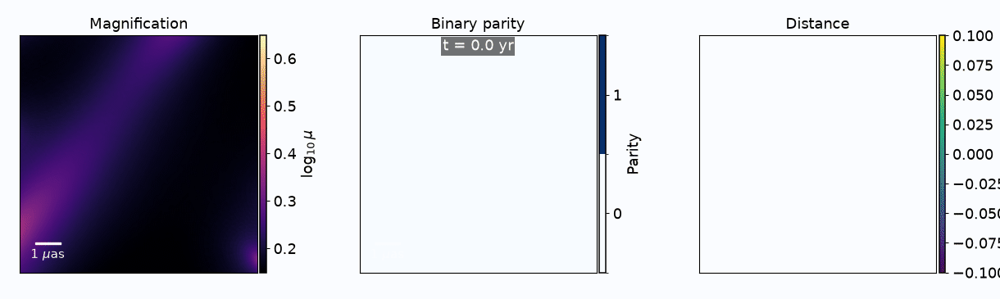

Wrote caustic_label_output\q2237b_magnification_binary_distance.gif
Frames: 147 diagnostic resolution: (256, 256)


In [6]:
import sys
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm
from IPython.display import Image, display

package_root = Path(mcp.__file__).resolve().parents[3]
examples_directory = package_root / "examples"
if str(examples_directory) not in sys.path:
    sys.path.insert(0, str(examples_directory))
from training_set_support import q2237_b_system

animation_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
training_system = q2237_b_system(
    seed=1001,
    driver_seed=12,
    device="cuda" if use_cuda else "cpu",
    times_days=torch.arange(-200.0, 3651.0),
    source_resolution=1024 if use_cuda else 256,
    label_resolution=8192 if use_cuda else 1024,
)
diagnostic_resolution = 256 if use_cuda else 128
diagnostic_grid = mc.PlaneGrid(
    (diagnostic_resolution, diagnostic_resolution),
    training_system.source_grid.field_of_view_uas,
    center_uas=training_system.source_grid.center_uas,
)
animation_method = mc.production_ipm_config(
    dynamic=True,
    rays=10_000_000 if use_cuda else 262_144,
)
animation_schedule = mc.production_dynamic_config()
animation_caustics = mc.CausticConfig(far_field_approx=animation_method.far_field_approx)

log_magnification_frames = []
binary_frames = []
distance_frames = []
caustic_segments = []
pool_factor = training_system.source_grid.shape[0] // diagnostic_resolution
for frame in training_system.simulation.dynamic_labeled_maps(
    training_system.lens_region,
    training_system.source_grid,
    training_system.lens_grid,
    animation_times.tolist(),
    method=animation_method,
    map_schedule=animation_schedule,
    caustic_config=animation_caustics,
    diagnostic_grid=diagnostic_grid,
    include_distance_map=True,
):
    values = frame.magnification_map.values
    if pool_factor > 1:
        values = torch.nn.functional.avg_pool2d(
            values[None, None], kernel_size=pool_factor, stride=pool_factor
        )[0, 0]
    log_magnification_frames.append(
        torch.log10(values.clamp_min(1.0e-12)).detach().cpu().numpy()
    )
    binary_frames.append(frame.caustics.label_map.values.detach().cpu().numpy())
    distance_frames.append(frame.caustics.distance_map.values_uas.detach().cpu().numpy())
    field = frame.caustics.caustics
    valid = field.invalid_segment_mask
    if valid is None:
        valid = torch.ones(field.segment_count, device=field.caustic_segments_uas.device, dtype=torch.bool)
    else:
        valid = ~valid
    caustic_segments.append(field.caustic_segments_uas[valid].detach().cpu().numpy())

log_magnification_frames = np.stack(log_magnification_frames)
binary_frames = np.stack(binary_frames)
distance_frames = np.stack(distance_frames)
mag_vmin, mag_vmax = np.nanquantile(log_magnification_frames, (0.002, 0.998))
distance_vmax = float(np.nanquantile(distance_frames, 0.998))

figure, axes = plt.subplots(1, 3, figsize=(12.2, 3.65))
common = dict(origin="lower", extent=diagnostic_grid.bounds_uas, aspect="equal")
artists = [
    axes[0].imshow(log_magnification_frames[0], cmap="magma", vmin=mag_vmin, vmax=mag_vmax, **common),
    axes[1].imshow(
        binary_frames[0], cmap=plt.colormaps["Blues"].resampled(2),
        norm=BoundaryNorm((-0.5, 0.5, 1.5), 2), interpolation="nearest", **common,
    ),
    axes[2].imshow(distance_frames[0], cmap="viridis", vmin=0.0, vmax=distance_vmax, **common),
]
titles = ("Magnification", "Binary parity", "Distance")
line_collections = []
for axis, title in zip(axes, titles, strict=True):
    axis.set_title(title)
    lines = LineCollection(caustic_segments[0], colors="white", linewidths=0.35, alpha=0.85)
    axis.add_collection(lines, autolim=False)
    line_collections.append(lines)
    axis.set_xlim(diagnostic_grid.bounds_uas[0], diagnostic_grid.bounds_uas[1])
    axis.set_ylim(diagnostic_grid.bounds_uas[2], diagnostic_grid.bounds_uas[3])
    mcp.add_scale_bar(axis, 1.0, label=r"1 $\mu$as", color="white")
    mcp.hide_image_axes(axis)
mcp.panel_colorbar(figure, axes[0], artists[0], label=r"$\log_{10}\mu$", size="2.5%", pad=0.035)
mcp.panel_colorbar(figure, axes[1], artists[1], label="Parity", ticks=(0, 1), size="2.5%", pad=0.035)
mcp.panel_colorbar(figure, axes[2], artists[2], label=r"Distance [$\mu$as]", size="2.5%", pad=0.035)
time_text = axes[1].text(
    0.50, 0.985, "", transform=axes[1].transAxes, ha="center", va="top",
    color="white", bbox={"facecolor": "black", "edgecolor": "none", "alpha": 0.55, "pad": 1.5},
)
# Reserve canvas space for the final colorbar and its labels.
figure.subplots_adjust(left=0.02, right=0.945, bottom=0.06, top=0.91, wspace=0.38)

rendered_frames = []
for frame_index, time_day in enumerate(animation_times):
    artists[0].set_data(log_magnification_frames[frame_index])
    artists[1].set_data(binary_frames[frame_index])
    artists[2].set_data(distance_frames[frame_index])
    for lines in line_collections:
        lines.set_segments(caustic_segments[frame_index])
    time_text.set_text(f"t = {float(time_day) / 365.0:.1f} yr")
    figure.canvas.draw()
    rendered_frames.append(np.asarray(figure.canvas.buffer_rgba())[..., :3].copy())

animation_directory = Path("caustic_label_output")
animation_directory.mkdir(exist_ok=True)
animation_path = animation_directory / "q2237b_magnification_binary_distance.gif"
mcp.save_fixed_palette_gif(rendered_frames, animation_path, fps=8, dither=True)
plt.close(figure)
display(Image(filename=str(animation_path)))
print("Wrote", animation_path)
print("Frames:", len(rendered_frames), "diagnostic resolution:", diagnostic_grid.shape)